In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy.wcs import WCS

# from helper_functions import *

## Image Setup
### Open the Image
Here we want to inspect the image and determine an effective area for star detection

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4784                                                  NAXIS2  =                 3194                                                  IMAGETYP= 'LIGHT'              / Type of exposure                               EXPOSURE=                 3720 / [s] Exposure duration                          EXPTIME =                120.0 / [s] Exposure duration                          DATE-LOC= '2024-11-02T21:42:52.264' / Time of observation (local)               DATE-OBS= '2024-11-03T03:42:52.264' / Time of observation (UTC)                 DATE-AVG= '2024-11-03T03:43:55.989' / Averaged midpoint time (UTC)              XBINNING=                    2 / X axis binning factor                          YBINNING=                    2 / Y axis 

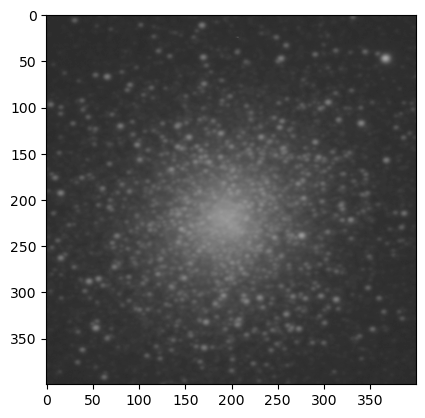

In [67]:
# open the images
imageB = fits.open("./twirl_B.fits")
imageR = fits.open("./twirl_R.fits")
print(imageB[0].header)

# crop the images
B_data = np.array(imageB[0].data, dtype=np.float32, copy=True) [1400:1800, 2200:2600]
R_data = np.array(imageR[0].data, dtype=np.float32, copy=True) [1400:1800, 2200:2600]

# plot the image
plt.imshow(B_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 

## Star Detection
### Calculate Sigma Clipped Statistics
We need the median value and standard deviation to use in our star detection


In [68]:
# library to use 
from astropy.stats import sigma_clipped_stats

mean, median_B, std = sigma_clipped_stats(B_data)
print(np.array((mean, median_B, std)))

mean, median_R, std = sigma_clipped_stats(R_data)
print(np.array((mean, median_R, std)))

[0.01319568 0.01080042 0.00599602]
[0.01112714 0.00965758 0.00365865]


### Star Finder
We will be using DAOFIND with median star detection for this step. Adjust the roundess limits until you have as many stars as possible

In [69]:
# library to use 
from photutils.detection import DAOStarFinder

# create a list of detected sources
daofind = DAOStarFinder(fwhm=4.0, threshold=1*std, roundlo=-1, roundhi=1.0)
sourcesB = daofind(B_data - median_B)
sourcesR = daofind(R_data - median_R)

# print table
sourcesR

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float32
1,57.50096483459975,0.6512674495429798,0.47431675770634674,-0.539656,-0.41441732302151335,25,0.0034823753,0.01702448,4.4223156,-0.31618538
2,331.3180756554091,2.8956211978970003,0.4639639366006159,-0.3852341,-0.27906947634992024,25,0.011884029,0.11720745,2.327612,-1.339123
3,30.50558372317876,6.183369766137612,0.46250530293489317,-0.19885561,-0.38192152856277284,25,0.043232698,0.4941322,0.7653921,-2.626439
4,208.10604990969787,6.848081397558422,0.711368558671948,-0.09876582,-0.6081966098466952,25,0.01851258,0.036118,3.6056905,-1.8919618
5,101.89996392087929,11.203652305278476,0.4602436627737648,-0.21966958,-0.26631842827399715,25,0.008518894,0.0745731,2.8185444,-1.0634521
6,296.3305028779902,11.387597771484032,0.4863645151726889,-0.34553143,-0.26102568765778783,25,0.0070597744,0.06973407,2.8913877,-0.73100126
7,54.300862179496626,12.42825759274033,0.43359082356634165,-0.19100325,-0.21002613154248675,25,0.004228412,0.030621318,3.7849402,-0.4450737
8,168.1422467362194,11.631803062333066,0.4426183398748072,-0.28509375,-0.24265072207269894,25,0.19294532,2.3408072,-0.9234141,-4.234033
9,199.9131658578735,11.88336105455135,0.42127183432271037,-0.96376526,-0.3614232837567406,25,0.0023642294,0.009207978,5.089589,-0.041452825


 ...]

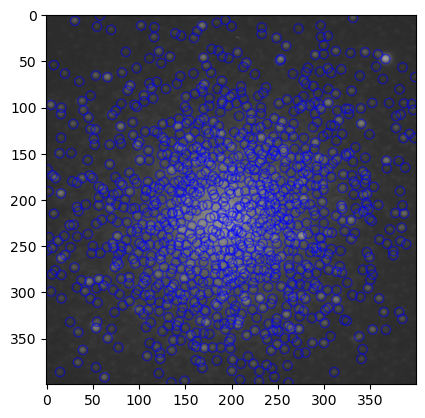

In [70]:
# library to use
from photutils.aperture import CircularAperture

# Why transpose? Hint: think about how the data is organized in a table and the expected input of CircularAperture
positions = np.transpose((sourcesB['xcentroid'], sourcesB['ycentroid']))
apertures = CircularAperture(positions, r=5.0)

# plot the image and circles
plt.imshow(B_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 
apertures.plot(color='blue', lw=1, alpha=0.5)

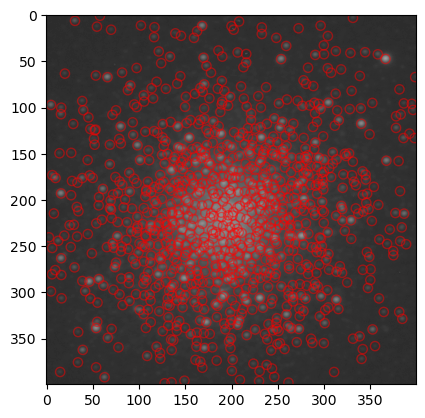

In [71]:
# repeat for second filter
positions = np.transpose((sourcesR['xcentroid'], sourcesR['ycentroid']))
apertures = CircularAperture(positions, r=5.0)

# plot the image
plt.imshow(R_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 
apertures.plot(color='red', lw=1, alpha=0.5)

In [72]:

# from astropy.io import fits
# from astropy.wcs import WCS
# from astropy.coordinates import SkyCoord
# import numpy as np

# # Load header and WCS
# header = fits.getheader("twirl_B.fits")
# wcs = WCS(header)

# print(wcs)  # Full WCS object details
# print("WCS ndim:", wcs.pixel_n_dim)
# print("WCS world axis types:", wcs.world_axis_physical_types)



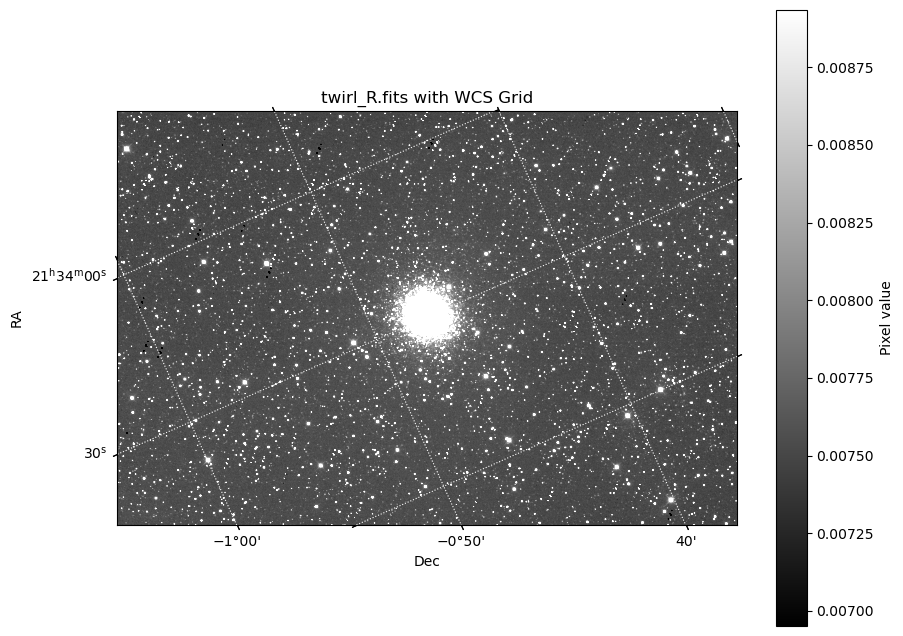

In [73]:
#TODO: rewrite

import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import (ZScaleInterval, ImageNormalize)

# Load image and WCS
hdu = fits.open("twirl_R.fits")[0]
wcs = WCS(hdu.header)
data = hdu.data

# Normalize image for better contrast
norm = ImageNormalize(data, interval=ZScaleInterval())

# Plot with WCS
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=wcs)
im = ax.imshow(data, origin='lower', cmap='gray', norm=norm)

# Add RA/Dec grid and labels
ax.coords.grid(True, color='white', ls='dotted')
ax.coords[0].set_axislabel('RA')
ax.coords[1].set_axislabel('Dec')

plt.title("twirl_R.fits with WCS Grid")
plt.colorbar(im, ax=ax, label="Pixel value")
plt.show()

323.379754065555 -0.776351508739938


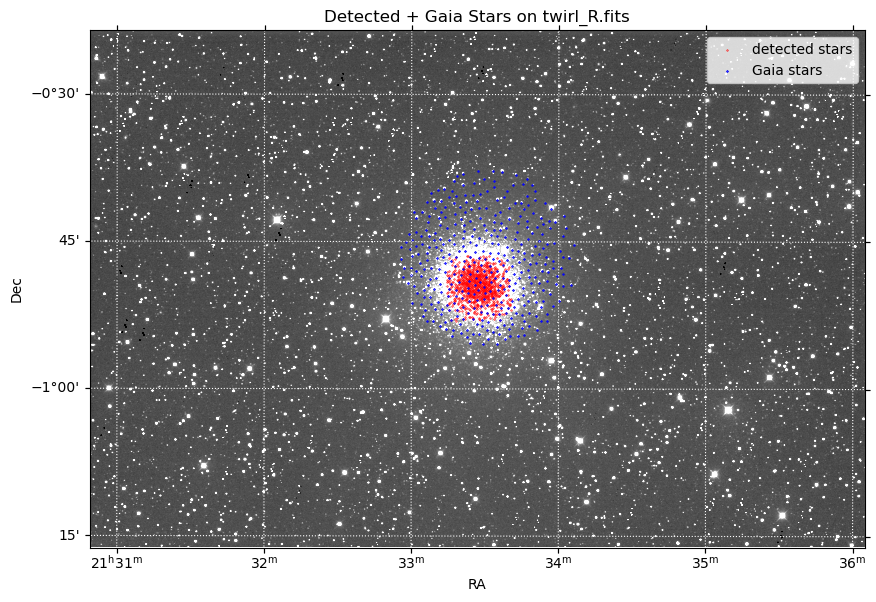

In [74]:

#TODO: rewrite

from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt
from twirl import gaia_radecs
from twirl.geometry import sparsify

# --- Load image and WCS ---
imageR = fits.open("twirl_B.fits")
# imageR = fits.open("R_MASTER_aligned.fits")

data = imageR[0].data
wcs = WCS(imageR[0].header)

# --- Normalize for display ---
norm = ImageNormalize(data, interval=ZScaleInterval())

# --- Load DAOStarFinder sources ---
sourcesR['xcentroid'] = sourcesR['xcentroid'] + 2200
sourcesR['ycentroid'] = sourcesR['ycentroid'] + 1400
sourcesB['xcentroid'] = sourcesB['xcentroid'] + 2200
sourcesB['ycentroid'] = sourcesB['ycentroid'] + 1400

x = sourcesR['xcentroid']
y = sourcesR['ycentroid']

# --- Fetch Gaia RA/Decs ---
ra = imageR[0].header['RA']
dec = imageR[0].header['DEC']

print(ra, dec)
all_radecs = gaia_radecs((ra, dec), 0.3)   # radius in degrees
all_radecs = sparsify(all_radecs, 0.01)
all_radecs = SkyCoord(all_radecs[:, 0], all_radecs[:, 1], unit='deg')


# --- Plot ---
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=wcs)
ax.imshow(data, origin='lower', cmap='gray', norm=norm)
ax.coords.grid(True, color='white', ls='dotted')

# Detected stars (in pixel space)
# ax.plot(x, y, 'o', markersize=1, color='red', alpha=0.2, label='Detected stars')

ax.scatter(x, y,
           s=1, color='red', alpha=0.5, marker='x', label='detected stars')

# Gaia stars (in RA/Dec sky coordinates)
ax.scatter(all_radecs.ra, all_radecs.dec, transform=ax.get_transform('world'),
           s=1, color='blue', alpha=0.8, marker='x', label='Gaia stars')

# Axis labels & legend
ax.coords[0].set_axislabel('RA')
ax.coords[1].set_axislabel('Dec')
plt.title("Detected + Gaia Stars on twirl_R.fits")
plt.legend()
plt.show()

In [75]:
#TODO: rewrite


from astropy.coordinates import SkyCoord
import astropy.units as u

sky_dao = wcs.pixel_to_world(x, y)

idx, d2d, _ = sky_dao.match_to_catalog_sky(all_radecs)
matched = d2d < 1.5 * u.arcsec

print(f"Matched {matched.sum()} / {len(sky_dao)} stars within 1.5 arcsec")

Matched 69 / 960 stars within 1.5 arcsec


In [76]:
# Get pixel centroids from DAOStarFinder
x = sourcesR['xcentroid']
y = sourcesR['ycentroid']

# Convert to RA/Dec
ra, dec = wcs.wcs_pix2world(x, y, 0)

sourcesR['RA'] = ra
sourcesR['DEC'] = dec

sourcesR


x = sourcesB['xcentroid']
y = sourcesB['ycentroid']

# Convert to RA/Dec
ra, dec = wcs.wcs_pix2world(x, y, 0)

sourcesB['RA'] = ra
sourcesB['DEC'] = dec

sourcesB

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,RA,DEC
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float32,float64,float64
1,2257.5072043051573,1400.559402297047,0.42507092196100027,-0.46668738,-0.22984502062545445,25,0.0028578574,0.004863715,5.78258,-0.36852908,323.32500435263006,-0.8839921864348071
2,2531.400049642815,1402.9616485304987,0.43290429204733505,-0.25960886,-0.3186974584098664,25,0.03987194,0.48347813,0.7890579,-2.5391288,323.40037266574427,-0.8831990826884543
3,2393.3379326036306,1405.182402484627,0.5535210220057523,0.11222995,0.13687665887990966,25,0.0051143058,0.046209916,3.338162,-0.32859153,323.3623801616634,-0.8826547735216868
4,2230.4695743604734,1406.2095165908738,0.44421042579341063,-0.3052951,-0.33380516575137287,25,0.053219534,0.6622664,0.44741824,-2.8001406,323.31756205134275,-0.8824504141405248
5,2383.9986300107507,1408.2827225272379,0.4309146905003932,-0.2321,-0.5268312705736786,25,0.006780667,0.06253801,3.0096397,-0.83241254,323.3598090006439,-0.881806168073751
6,2302.0493881782,1411.3164186584859,0.4405233506576202,-0.18075979,-0.23177490889838973,25,0.030198196,0.35311514,1.1302091,-2.2606525,323.3372572425864,-0.881010827307764
7,2496.414292818392,1411.3230654821857,0.43982340154863847,-0.31586656,-0.1551058883744999,25,0.0047136713,0.040739514,3.4749603,-0.4691084,323.3907421204525,-0.8809152462225551
8,2254.3242035433273,1412.4180561463481,0.41208484431701836,-0.11226571,-0.16398122128561807,25,0.0050474666,0.03641439,3.5968175,-0.6848725,323.32412393222376,-0.8807305952588194
9,2368.1701647929053,1411.660619923787,0.4386420392472822,-0.227298,-0.24282548365206316,25,0.16404235,2.1054072,-0.8083403,-4.000373,323.35545206196963,-0.880884306953987


### Stetson Matching

In [77]:
import pandas as pd

mags = pd.read_csv("NGC7089.pho", sep='[ ]{1,}', engine='python')
mags

,Reference,U,sigma,N,n,B,sigma.1,N.1,n.1,V,...,n.2,R,sigma.3,N.3,n.3,I,sigma.4,N.4,n.4,vary?
0,M2-S1,18.893,0.0053,24,34,19.029,0.0042,49,64,18.412,...,106,18.031,0.0059,22,30,17.617,0.0037,94,110,-0.117
1,M2-S2,16.843,0.0054,25,39,16.647,0.0037,53,70,15.794,...,109,15.287,0.0056,32,45,14.793,0.0036,69,89,0.021
2,M2-S4,18.754,0.0089,24,37,18.819,0.0057,53,69,18.157,...,111,17.762,0.0094,22,30,17.327,0.0050,96,115,0.033
3,M2-S6,17.380,0.0037,25,39,17.355,0.0030,54,72,16.604,...,103,16.143,0.0036,29,41,15.683,0.0024,75,96,-0.096
4,M2-S8,16.491,0.0067,25,37,16.549,0.0037,56,72,16.541,...,126,16.534,0.0090,26,37,16.525,0.0025,97,113,0.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,M2-S1662,99.999,9.9999,0,0,99.999,9.9999,0,0,17.878,...,14,99.999,9.9999,0,0,17.017,0.0076,12,13,-0.079
1441,M2-S1663,99.999,9.9999,0,0,19.466,0.0109,9,12,18.872,...,20,99.999,9.9999,0,0,18.084,0.0125,13,16,-0.036
1442,M2-S1664,99.999,9.9999,0,0,16.918,0.0068,7,8,16.279,...,8,99.999,9.9999,0,0,15.454,0.0091,6,7,-0.069
1443,M2-S1665,16.383,0.0146,5,7,16.335,0.0111,8,14,15.676,...,15,99.999,9.9999,0,0,14.848,0.0101,9,14,0.027


In [78]:
coords = pd.read_csv("NGC7089.pos", sep='[ ]{2,}', engine='python')
coords.rename(columns={'323.36209232807' : 'RA', '-00.84555554920' : 'DEC'}, inplace=True)

# the try block is here if you run the code twice and the spaces have been replaced alreadi
try : coords['DEC'] = coords['DEC'].str.replace(" ", "")  
except: pass

coords['DEC'] = coords['DEC'].astype(float)
coords.dtypes

RA                         float64
DEC                        float64
21 33 26.90 -00 50 44.0     object
0.00                       float64
0.00.1                     float64
8138.0                     float64
7118.0                     float64
Reference                   object
dtype: object

In [79]:
stetson = pd.merge(coords[['Reference', 'RA', 'DEC']], mags, how='inner', on=['Reference'])
stetson

,Reference,RA,DEC,U,sigma,N,n,B,sigma.1,N.1,...,n.2,R,sigma.3,N.3,n.3,I,sigma.4,N.4,n.4,vary?
0,M2-S1,323.394972,-0.862217,18.893,0.0053,24,34,19.029,0.0042,49,...,106,18.031,0.0059,22,30,17.617,0.0037,94,110,-0.117
1,M2-S2,323.388666,-0.825776,16.843,0.0054,25,39,16.647,0.0037,53,...,109,15.287,0.0056,32,45,14.793,0.0036,69,89,0.021
2,M2-S4,323.392878,-0.848818,18.754,0.0089,24,37,18.819,0.0057,53,...,111,17.762,0.0094,22,30,17.327,0.0050,96,115,0.033
3,M2-S6,323.390901,-0.836977,17.380,0.0037,25,39,17.355,0.0030,54,...,103,16.143,0.0036,29,41,15.683,0.0024,75,96,-0.096
4,M2-S8,323.395248,-0.860628,16.491,0.0067,25,37,16.549,0.0037,56,...,126,16.534,0.0090,26,37,16.525,0.0025,97,113,0.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,M2-S1662,323.572509,-0.626387,99.999,9.9999,0,0,99.999,9.9999,0,...,14,99.999,9.9999,0,0,17.017,0.0076,12,13,-0.079
1441,M2-S1663,323.573094,-0.883147,99.999,9.9999,0,0,19.466,0.0109,9,...,20,99.999,9.9999,0,0,18.084,0.0125,13,16,-0.036
1442,M2-S1664,323.574565,-0.606674,99.999,9.9999,0,0,16.918,0.0068,7,...,8,99.999,9.9999,0,0,15.454,0.0091,6,7,-0.069
1443,M2-S1665,323.577047,-0.912129,16.383,0.0146,5,7,16.335,0.0111,8,...,15,99.999,9.9999,0,0,14.848,0.0101,9,14,0.027


In [80]:
try: sourcesR = sourcesR.to_pandas()
except: pass

sourcesR.rename(columns={"mag": "det_magR"}, inplace=True)


try: sourcesB = sourcesB.to_pandas()
except: pass

sourcesB.rename(columns={"mag": "det_magB"}, inplace=True)

In [81]:
from astropy.coordinates import SkyCoord
import astropy.units as u

sources_sky = SkyCoord(ra=sourcesR['RA'].values * u.deg,
                       dec=sourcesR['DEC'].values * u.deg)
stetson_sky = SkyCoord(ra=stetson['RA'].values * u.deg,
                       dec=stetson['DEC'].values * u.deg)

idx, sep2d, _ = sources_sky.match_to_catalog_sky(stetson_sky)
matches = sep2d < 1 * u.arcsec  # 174 matches


# Select matched rows
matched_sources = sourcesR[matches].reset_index(drop=True)
matched_stetson = stetson.iloc[idx[matches]].reset_index(drop=True)


# Choose the columns you want to keep from each side
cols_sources = ['det_magR', 'RA', 'DEC']
cols_stetson = ['Reference', 'R', 'B']  # or whatever photometric bands you want

full = matched_sources[cols_sources].join(matched_stetson[cols_stetson])

full

,det_magR,RA,DEC,Reference,R,B
0,2.327612,323.400350,-0.883217,M2-S24,16.250,16.318
1,2.818544,323.337216,-0.881042,M2-S806,16.571,16.597
2,2.084390,323.353931,-0.879301,M2-S509,16.299,17.507
3,1.814598,323.342500,-0.873310,M2-S487,15.940,16.263
4,0.982897,323.407747,-0.872337,M2-S95,15.270,16.583
...,...,...,...,...,...,...
170,2.160025,323.342815,-0.781800,M2-S488,16.271,16.347
171,1.005938,323.364383,-0.781484,M2-S525,15.317,16.609
172,1.607678,323.374496,-0.779907,M2-S537,15.786,17.031
173,4.090312,323.394596,-0.777750,M2-S565,17.302,17.164


In [82]:
sourcesB

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,det_magB,daofind_mag,RA,DEC
0,1,2257.507204,1400.559402,0.425071,-0.466687,-0.229845,25,0.002858,0.004864,5.782580,-0.368529,323.325004,-0.883992
1,2,2531.400050,1402.961649,0.432904,-0.259609,-0.318697,25,0.039872,0.483478,0.789058,-2.539129,323.400373,-0.883199
2,3,2393.337933,1405.182402,0.553521,0.112230,0.136877,25,0.005114,0.046210,3.338162,-0.328592,323.362380,-0.882655
3,4,2230.469574,1406.209517,0.444210,-0.305295,-0.333805,25,0.053220,0.662266,0.447418,-2.800141,323.317562,-0.882450
4,5,2383.998630,1408.282723,0.430915,-0.232100,-0.526831,25,0.006781,0.062538,3.009640,-0.832413,323.359809,-0.881806
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1061,1062,2409.067134,1794.884862,0.414101,-0.390996,-0.006672,25,0.005574,0.065036,2.967122,-0.476911,323.366558,-0.775414
1062,1063,2349.080536,1795.679582,0.445118,0.006486,-0.203480,25,0.017641,0.230158,1.594934,-1.546819,323.350052,-0.775224
1063,1064,2429.755189,1796.133694,0.450095,-0.169614,-0.316711,25,0.016408,0.190730,1.798954,-1.583853,323.372251,-0.775060
1064,1065,2334.850554,1797.507208,0.457835,0.042649,-0.297948,25,0.005381,0.058192,3.087849,-0.411498,323.346135,-0.774728


In [83]:
#TODO: rewrite

from astropy.coordinates import SkyCoord
import astropy.units as u

# SkyCoords for R-matched stars (from `full`)
coords_R = SkyCoord(ra=full['RA'].values * u.deg,
                    dec=full['DEC'].values * u.deg)

# SkyCoords for detected B-band sources
coords_B = SkyCoord(ra=sourcesB['RA'].values * u.deg,
                    dec=sourcesB['DEC'].values * u.deg)


idx, sep2d, _ = coords_R.match_to_catalog_sky(coords_B)
matches = sep2d < 1.0 * u.arcsec

# Only keep matches within threshold
matched_R = full[matches].reset_index(drop=True)
matched_B = sourcesB.iloc[idx[matches]].reset_index(drop=True)

# Rename B-band mag to avoid name clash
matched_B = matched_B.rename(columns={'mag': 'det_magB'})

# Join det_magB into full table
full = matched_R.join(matched_B[['det_magB']])

full

full.to_csv("detected_stetson.csv", index=False)

In [84]:
# find average difference from full matches to detected red filter?
diffR = sum(full["det_magR"] - full["R"]) / len(full)
diffR

-14.312363991585464

In [85]:
# find average difference from full matches to detected blue filter?
diffB = sum(full["det_magB"] - full["B"]) / len(full)
diffB

-15.873573073808801

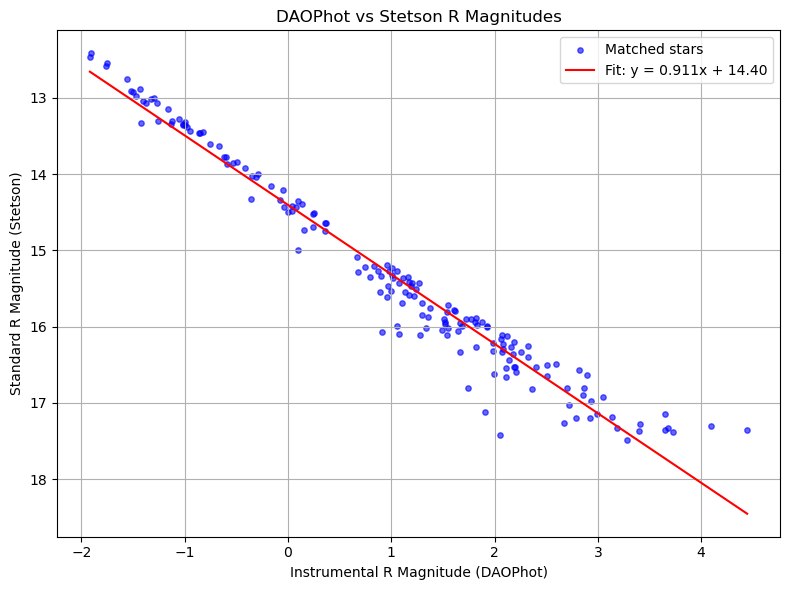

In [86]:
#TODO: rewrite

import matplotlib.pyplot as plt
from scipy.stats import linregress

R_inst = full["det_magR"]   # from DAOPhot
R_stetson = full["R"]  # from Stetson .pho

# Linear fit: R_stetson = a * R_inst + b
slope, intercept, r_value, p_value, std_err = linregress(R_inst, R_stetson)

# Generate best-fit line
x_fit = np.linspace(min(R_inst), max(R_inst), 100)
y_fit = slope * x_fit + intercept

# Plot
plt.figure(figsize=(8,6))
plt.scatter(R_inst, R_stetson, s=15, color='blue', alpha=0.6, label='Matched stars')
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {slope:.3f}x + {intercept:.2f}')
plt.xlabel('Instrumental R Magnitude (DAOPhot)')
plt.ylabel('Standard R Magnitude (Stetson)')
plt.title('DAOPhot vs Stetson R Magnitudes')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()  # fainter magnitudes are higher values
plt.tight_layout()
plt.show()

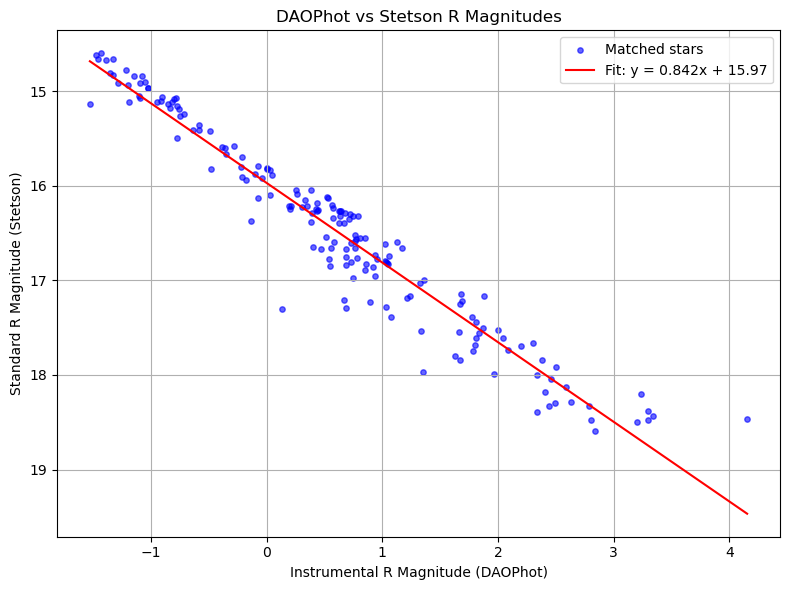

In [87]:
#TODO: rewrite

import matplotlib.pyplot as plt
from scipy.stats import linregress

# Example column names — adjust if yours differ
R_inst = full["det_magB"]   # from DAOPhot
R_stetson = full["B"]  # from Stetson .pho

# Linear fit: R_stetson = a * R_inst + b
slope, intercept, r_value, p_value, std_err = linregress(R_inst, R_stetson)

# Generate best-fit line
x_fit = np.linspace(min(R_inst), max(R_inst), 100)
y_fit = slope * x_fit + intercept

# Plot
plt.figure(figsize=(8,6))
plt.scatter(R_inst, R_stetson, s=15, color='blue', alpha=0.6, label='Matched stars')
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {slope:.3f}x + {intercept:.2f}')
plt.xlabel('Instrumental R Magnitude (DAOPhot)')
plt.ylabel('Standard R Magnitude (Stetson)')
plt.title('DAOPhot vs Stetson R Magnitudes')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()  # fainter magnitudes are higher values
plt.tight_layout()
plt.show()

In [88]:
# from numpy.polynomial.polynomial import polyfit

# # Fit: R_stetson = a × det_magR + b
# a, b = polyfit(full['det_magR'], full['R'], 1)

# print(f"Calibration equation: R = {a:.6f} × det_magR + {b:.6f}")

# # Apply calibrated magnitudes
# full['calib_magR'] = a * full['det_magR'] + b

In [89]:
# R_mags = full['R']
# colour = full['B'] - full['R']

# R_mags = full["det_magR"] - diffR
# B_mags = full["det_magB"] - diffB

R_mags = 0.91 * full["det_magR"] + 14.4
B_mags = 0.84 * full["det_magB"] + 15.94

colour = B_mags - R_mags

# colour = full["B"] - R_mags

# R_mags = sourcesR["det_magR"] - diff
# colour = sourcesB['det_magB'] - R_mags


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


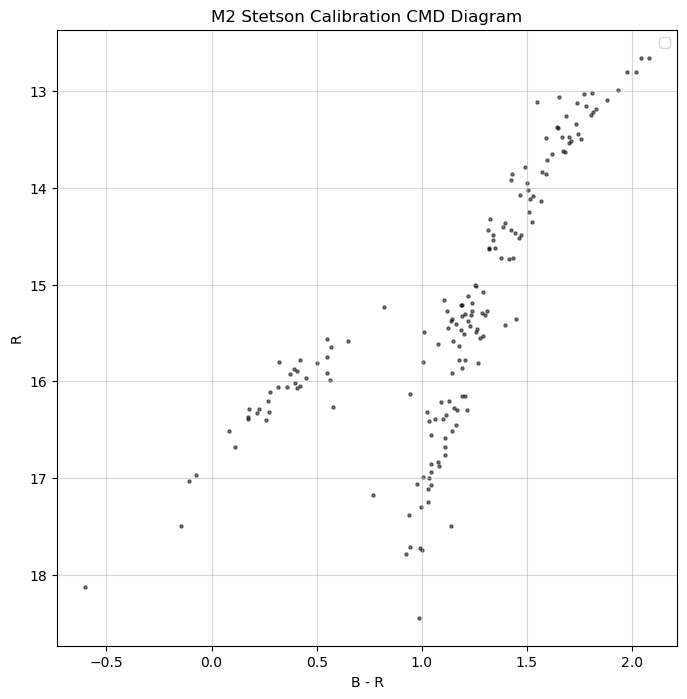

In [90]:
fig, ax = plt.subplots(figsize=(8,8))

ax.set_title("M2 Stetson Calibration CMD Diagram")
ax.set_xlabel("B - R")
ax.set_ylabel("R")
ax.scatter(colour, R_mags, s=5, alpha=0.5, color="black") 
ax.grid(alpha=0.5)
ax.invert_yaxis()


ax.legend()
plt.show()

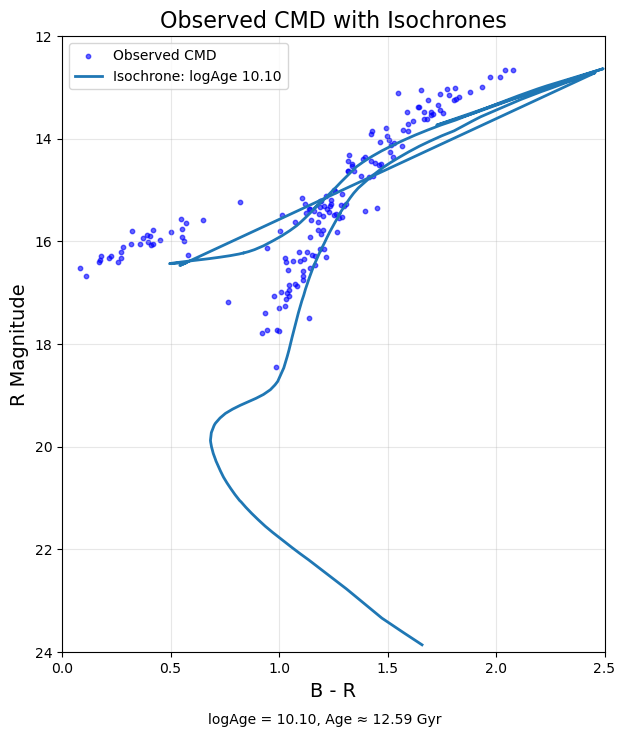

logAge = 10.10, Age ≈ 12.59 Gyr


In [91]:
#TODO: rewrite

import pandas as pd
import matplotlib.pyplot as plt

# --- SETTINGS ---
iso_file = "isochrone.dat.txt"  # update to your file name
distance_modulus = 16.15  # for M2 at ~17 kpc
# https://stev.oapd.inaf.it/cgi-bin/cmd_3.8

# Column names based on CMD output
columns = [
    'Zini','MH','logAge','Mini','int_IMF','Mass','logL','logTe','logg',
    'label','McoreTP','C_O','period0','period1','period2','period3','period4',
    'pmode','Mloss','tau1m','X','Y','Xc','Xn','Xo','Cexcess','Z',
    'mbolmag','Umag','Bmag','Vmag','Rmag','Imag','Jmag','Hmag','Kmag'
]

# Load isochrone file, skip comment lines
iso = pd.read_csv(iso_file, sep=r"\s+", comment="#", names=columns)

# --- Process Isochrones ---
fig, ax = plt.subplots(figsize=(7, 8))

ax.set_xlim(0, 2.5)  
ax.set_ylim(24, 12) 

# Your observed CMD (replace with your arrays)
ax.scatter(colour, R_mags, s=10, alpha=0.6, color='blue', label='Observed CMD')

# Group by age if multiple
for age, group in iso.groupby('logAge'):
    color = group['Bmag'] - group['Rmag']
    mag_R = group['Rmag'] + distance_modulus

    # Apply mask
    mask = (color > 0) & (color < 2.5) & (mag_R > 12) & (mag_R < 24)

    ax.plot(color[mask], mag_R[mask], lw=2, label=f'Isochrone: logAge {age:.2f}')

# Plot styling
# ax.invert_yaxis()
ax.set_xlabel('B - R', fontsize=14)
ax.set_ylabel('R Magnitude', fontsize=14)
ax.set_title('Observed CMD with Isochrones', fontsize=16)
ax.legend()
ax.grid(alpha=0.3)
text = fig.text(0.50, 0.02, 'logAge = 10.10, Age ≈ 12.59 Gyr',  horizontalalignment='center', wrap=True )
plt.show()

for age, group in iso.groupby('logAge'):
    age_gyr = 10**age / 1e9
    print(f"logAge = {age:.2f}, Age ≈ {age_gyr:.2f} Gyr")

In [92]:
#TODO: rewrite


import numpy as np

# Assume sources_B and sources_R are the tables from DAOStarFinder
x_B = np.array(sourcesB['xcentroid'])
y_B = np.array(sourcesB['ycentroid'])

x_R = np.array(sourcesR['xcentroid'])
y_R = np.array(sourcesR['ycentroid'])

matches = []  # list of tuples (i_B, i_R, distance)

tolerance = 2  # pixels

for i, (xb, yb) in enumerate(zip(x_B, y_B)):
    # Compute distances to all R stars
    dist = np.sqrt((x_R - xb)**2 + (y_R - yb)**2)
    
    j = np.argmin(dist)  # index of closest R star
    if dist[j] <= tolerance:
        matches.append((i, j, dist[j]))

print(f"Matched {len(matches)} stars within {tolerance} px")

# Example: print first few matches
for m in matches[:10]:
    i_B, i_R, d = m
    print(f"B star {i_B} matched with R star {i_R}, distance = {d:.2f}")
    
    
# Initialize lists
B_mags = []
R_mags = []

# Loop through your matched pixel indices
for i_B, i_R, _ in matches:
    B_mags.append(sourcesB.iloc[i_B]['det_magB'])
    R_mags.append(sourcesR.iloc[i_R]['det_magR'])

# Optional: convert to numpy arrays if needed
import numpy as np
B_mags = np.array(B_mags)
R_mags = np.array(R_mags) 


Matched 906 stars within 2 px
B star 0 matched with R star 0, distance = 0.09
B star 1 matched with R star 1, distance = 0.11
B star 3 matched with R star 2, distance = 0.04
B star 5 matched with R star 4, distance = 0.19
B star 6 matched with R star 5, distance = 0.11
B star 7 matched with R star 6, distance = 0.03
B star 8 matched with R star 7, distance = 0.04
B star 9 matched with R star 8, distance = 0.15
B star 10 matched with R star 9, distance = 0.14
B star 11 matched with R star 10, distance = 0.10


In [93]:
R_mags

array([ 4.42231560e+00,  2.32761192e+00,  7.65392125e-01,  2.81854439e+00,
        2.89138770e+00,  3.78494024e+00, -9.23414111e-01,  5.08958912e+00,
        3.69620132e+00,  4.31946993e+00,  4.51539326e+00,  2.92272186e+00,
        2.08438969e+00,  2.54561543e+00,  2.56190777e+00,  3.55693245e+00,
        2.96157646e+00,  1.65318680e+00,  1.94503844e+00,  1.95906866e+00,
        2.50935405e-01,  2.67719316e+00,  3.47806644e+00,  1.81459832e+00,
        2.07622743e+00,  1.28443170e+00,  1.53080916e+00,  2.54107690e+00,
        3.21744347e+00,  9.82896686e-01,  3.71541500e-01,  1.02022791e+00,
        2.93289661e+00, -6.71470106e-01, -2.94075847e+00, -1.16334093e+00,
        1.13234520e+00, -1.16334093e+00,  4.00936937e+00,  1.09962916e+00,
        2.24002147e+00,  3.29941368e+00,  3.65325642e+00,  2.19370747e+00,
        2.92145014e+00,  1.55099177e+00,  3.26175117e+00,  3.38077974e+00,
        2.48072648e+00,  1.82463145e+00,  3.19439459e+00,  3.67797518e+00,
       -9.93798673e-01,  

In [94]:
cal_R = 0.91 * R_mags + 14.4
cal_B = 0.84 * B_mags + 15.94

cal_R = R_mags # - diffR
cal_B = B_mags # - diffB

len(cal_R)

R_mags = cal_R
colour = cal_B - cal_R

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


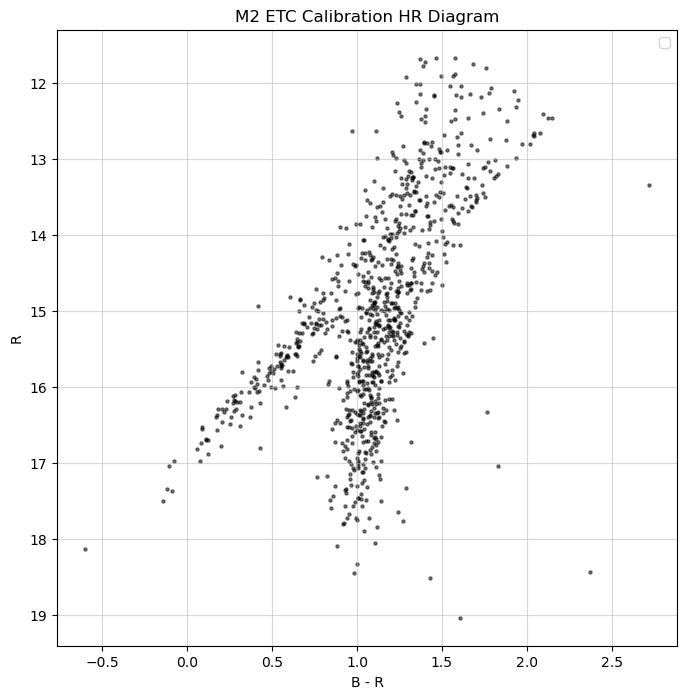

In [95]:
cal_R = 0.91 * R_mags + 14.4
cal_B = 0.84 * B_mags + 15.94
R_mags = cal_R
colour = cal_B - cal_R

fig, ax = plt.subplots(figsize=(8,8))

ax.set_title("M2 ETC Calibration HR Diagram")
ax.set_xlabel("B - R")
ax.set_ylabel("R")
ax.scatter(colour, R_mags, s=5, alpha=0.5, color="black") 
ax.grid(alpha=0.5)
ax.invert_yaxis()


ax.legend()
plt.show()

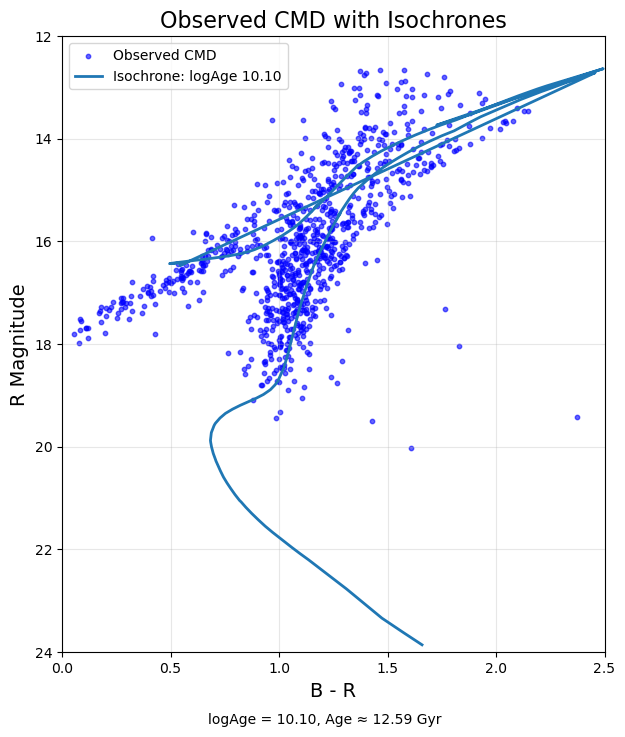

logAge = 10.10, Age ≈ 12.59 Gyr


In [96]:
#TODO: rewrite

import pandas as pd
import matplotlib.pyplot as plt

# --- SETTINGS ---
iso_file = "isochrone.dat.txt"  # update to your file name
distance_modulus = 16.15  # for M2 at ~17 kpc

# Column names based on CMD output
columns = [
    'Zini','MH','logAge','Mini','int_IMF','Mass','logL','logTe','logg',
    'label','McoreTP','C_O','period0','period1','period2','period3','period4',
    'pmode','Mloss','tau1m','X','Y','Xc','Xn','Xo','Cexcess','Z',
    'mbolmag','Umag','Bmag','Vmag','Rmag','Imag','Jmag','Hmag','Kmag'
]

# Load isochrone file, skip comment lines
iso = pd.read_csv(iso_file, sep=r"\s+", comment="#", names=columns)

# --- Process Isochrones ---
fig, ax = plt.subplots(figsize=(7, 8))

ax.set_xlim(0, 2.5)  
ax.set_ylim(24, 12) 

# Your observed CMD (replace with your arrays)
ax.scatter(colour, R_mags + 1, s=10, alpha=0.6, color='blue', label='Observed CMD')

# Group by age if multiple
for age, group in iso.groupby('logAge'):
    color = group['Bmag'] - group['Rmag']
    mag_R = group['Rmag'] + distance_modulus

    # Apply mask
    mask = (color > 0) & (color < 2.5) & (mag_R > 12) & (mag_R < 24)

    ax.plot(color[mask], mag_R[mask], lw=2, label=f'Isochrone: logAge {age:.2f}')

# Plot styling
# ax.invert_yaxis()
ax.set_xlabel('B - R', fontsize=14)
ax.set_ylabel('R Magnitude', fontsize=14)
ax.set_title('Observed CMD with Isochrones', fontsize=16)
ax.legend()
ax.grid(alpha=0.3)
text = fig.text(0.50, 0.02, 'logAge = 10.10, Age ≈ 12.59 Gyr',  horizontalalignment='center', wrap=True )
plt.show()

for age, group in iso.groupby('logAge'):
    age_gyr = 10**age / 1e9
    print(f"logAge = {age:.2f}, Age ≈ {age_gyr:.2f} Gyr")